In [ ]:
!pip install -q qiskit qiskit-aer pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00


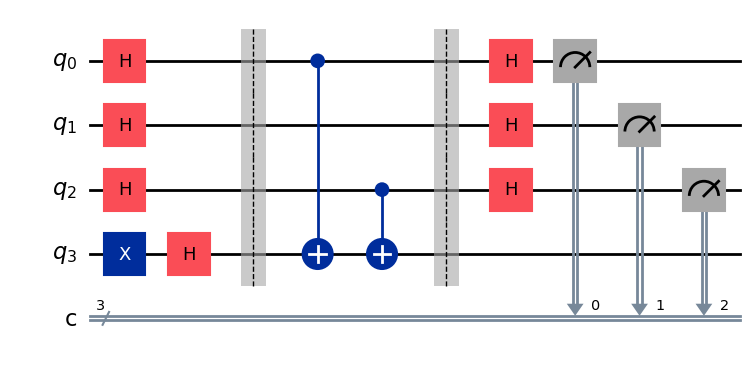

Measurement results: {'101': 1024}
Secret number is: 101


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Secret number
secretNumber = "101"

n = len(secretNumber)

# n input qubits + 1 ancilla qubit
# n classical bits for measurement
circuit = QuantumCircuit(n + 1, n)

# ----------------------------------
# Step 1: Prepare the ancilla |1>
# ----------------------------------
circuit.x(n)

# ----------------------------------
# Step 2: Apply Hadamard gates
# ----------------------------------
for qubit in range(n + 1):
    circuit.h(qubit)

circuit.barrier()

# ----------------------------------
# Step 3: Bernstein-Vazirani Oracle
# ----------------------------------
# Reverse because Qiskit uses little-endian qubit ordering
for i, bit in enumerate(reversed(secretNumber)):
    if bit == '1':
        circuit.cx(i, n)

circuit.barrier()

# ----------------------------------
# Step 4: Apply Hadamard gates
# to input qubits
# ----------------------------------
for qubit in range(n):
    circuit.h(qubit)

# ----------------------------------
# Step 5: Measure input qubits
# ----------------------------------
for qubit in range(n):
    circuit.measure(qubit, qubit)

# Display circuit
display(circuit.draw("mpl"))

# ----------------------------------
# Step 6: Run on simulator
# ----------------------------------
simulator = AerSimulator()

result = simulator.run(
    circuit,
    shots=1024
).result()

counts = result.get_counts()

print("Measurement results:", counts)

# Display histogram
plot_histogram(counts)
plt.show()

# Most probable result
answer = max(counts, key=counts.get)

print("Secret number is:", answer)